# Learning to Play Blackjack with Reinforcement Learning

This notebook compares four Blackjack policies:

1. **Random policy**: randomly hits or stands.
2. **Stand on 17+ policy**: hits below 17, stands at 17 or higher.
3. **Stand on 18+ policy**: hits below 18, stands at 18 or higher.
4. **Q-learning policy**: learns when to hit or stand through reinforcement learning.

For presentation-quality results, this version uses:

- `TRAINING_EPISODES = 500_000`
- `N_TEST_EPISODES = 10_000`

If you only want to test that the notebook runs quickly, temporarily lower these values to:

```python
TRAINING_EPISODES = 20_000
N_TEST_EPISODES = 100
```

## 1. Install and Import Dependencies

Run the install cell once if your environment does not already have the right packages.  
After installing packages, restart the kernel before running the import cell.

In [1]:
# Run this cell only if imports fail.
# The versions are pinned to avoid the NumPy mismatch error.

# %pip install --no-cache-dir numpy==1.26.4 gymnasium==0.29.1 matplotlib==3.8.4

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

print("Imports worked!")
print(f"Gymnasium version: {gym.__version__}")
print(f"NumPy version: {np.__version__}")

Imports worked!
Gymnasium version: 0.29.1
NumPy version: 1.26.4


## 2. Set Up the Blackjack Environment

The Gymnasium Blackjack environment uses:

- **State:** `(player_sum, dealer_showing_card, usable_ace)`
- **Actions:** `0 = Stand`, `1 = Hit`
- **Rewards:** `+1 = Win`, `0 = Draw`, `-1 = Lose`

In [3]:
def make_env():
    """Create a new Blackjack environment."""
    return gym.make("Blackjack-v1", sab=True)


# Create one environment just to inspect the spaces.
env = make_env()

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print("Actions: 0 = Stand, 1 = Hit")

env.close()

Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space: Discrete(2)
Actions: 0 = Stand, 1 = Hit


## 3. Quick Sample Episodes

In [4]:
# This cell is only for demonstration.
# It shows what one or two random Blackjack hands look like.

sample_env = make_env()

print("=== Sample Episodes ===")

for episode in range(2):
    state, info = sample_env.reset(seed=episode)
    print(f"\nEpisode {episode + 1}:")
    print(f"  Initial state: player_sum={state[0]}, dealer_card={state[1]}, usable_ace={state[2]}")

    done = False
    step = 0

    while not done:
        action = sample_env.action_space.sample()
        action_name = "Hit" if action == 1 else "Stand"

        next_state, reward, terminated, truncated, info = sample_env.step(action)
        done = terminated or truncated
        step += 1

        print(f"  Step {step}: Action={action_name}, New state={next_state}, Reward={reward}, Done={done}")
        state = next_state

    result = "Win" if reward > 0 else ("Draw" if reward == 0 else "Lose")
    print(f"  Result: {result}")

sample_env.close()

=== Sample Episodes ===

Episode 1:
  Initial state: player_sum=11, dealer_card=10, usable_ace=0
  Step 1: Action=Hit, New state=(12, 10, 0), Reward=0.0, Done=False
  Step 2: Action=Stand, New state=(12, 10, 0), Reward=-1.0, Done=True
  Result: Lose

Episode 2:
  Initial state: player_sum=20, dealer_card=7, usable_ace=0
  Step 1: Action=Hit, New state=(22, 7, 0), Reward=-1.0, Done=True
  Result: Lose


## 4. Settings, Baselines, and Evaluation

Every policy function below uses the same format:

```python
policy_function(state) -> action
```

This prevents function mismatch errors.

In [5]:
# Main settings.
# For a quick test, change these to 20_000 and 100.
# For final presentation-quality results, keep these higher values.

TRAINING_EPISODES = 500_000
N_TEST_EPISODES = 10_000

print(f"Training episodes: {TRAINING_EPISODES:,}")
print(f"Testing episodes per policy: {N_TEST_EPISODES:,}")

Training episodes: 500,000
Testing episodes per policy: 10,000


In [6]:
def random_policy(state):
    """Baseline 1: randomly choose stand or hit."""
    return int(np.random.randint(0, 2))


def stand_on_17_policy(state):
    """Baseline 2: hit below 17, stand on 17 or higher."""
    player_sum, dealer_card, usable_ace = state
    return 1 if player_sum < 17 else 0


def stand_on_18_policy(state):
    """Baseline 3: hit below 18, stand on 18 or higher."""
    player_sum, dealer_card, usable_ace = state
    return 1 if player_sum < 18 else 0


def evaluate_policy(policy_fn, n_episodes=None, seed=123):
    """
    Evaluate a policy over many Blackjack hands.

    Args:
        policy_fn: function that takes a state and returns an action
        n_episodes: number of test hands
        seed: random seed for repeatable results

    Returns:
        A dictionary with win_rate, draw_rate, lose_rate, and average_reward.
    """
    if n_episodes is None:
        n_episodes = N_TEST_EPISODES

    test_env = make_env()

    # This makes random_policy and environment outcomes more repeatable.
    np.random.seed(seed)
    test_env.action_space.seed(seed)

    wins = 0
    draws = 0
    losses = 0
    total_reward = 0

    for episode in range(n_episodes):
        state, info = test_env.reset(seed=seed + episode)
        done = False

        while not done:
            action = policy_fn(state)
            state, reward, terminated, truncated, info = test_env.step(action)
            done = terminated or truncated

        total_reward += reward

        if reward > 0:
            wins += 1
        elif reward == 0:
            draws += 1
        else:
            losses += 1

    test_env.close()

    return {
        "win_rate": wins / n_episodes,
        "draw_rate": draws / n_episodes,
        "lose_rate": losses / n_episodes,
        "average_reward": total_reward / n_episodes
    }

## 5. Train the Q-Learning Agent

The Q-table stores two values for each state:

- `Q[state][0]` = learned value for **standing**
- `Q[state][1]` = learned value for **hitting**

The agent starts by exploring often, then slowly explores less as training continues.

In [7]:
def choose_epsilon_greedy_action(Q, state, epsilon, rng):
    """
    Choose an action using epsilon-greedy behavior.

    With probability epsilon, choose a random action.
    Otherwise, choose the best action in the Q-table.
    """
    if rng.random() < epsilon:
        return int(rng.integers(0, 2))  # 0 = stand, 1 = hit

    return int(np.argmax(Q[state]))


def train_q_learning(
    n_episodes=None,
    alpha=0.03,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_end=0.01,
    seed=42
):
    """
    Train a Q-learning agent for Blackjack.

    Args:
        n_episodes: number of training hands
        alpha: learning rate
        gamma: discount factor
        epsilon_start: exploration rate at the beginning
        epsilon_end: exploration rate at the end
        seed: random seed

    Returns:
        Q: learned Q-table
        training_rewards: reward from each training hand
    """
    if n_episodes is None:
        n_episodes = TRAINING_EPISODES

    train_env = make_env()
    rng = np.random.default_rng(seed)

    # Q[state] is an array with two values:
    # index 0 = stand value, index 1 = hit value.
    Q = defaultdict(lambda: np.zeros(2))
    training_rewards = []

    print(f"Training Q-learning agent with {n_episodes:,} hands...")

    report_every = max(1, n_episodes // 5)

    for episode in range(1, n_episodes + 1):
        state, info = train_env.reset(seed=seed + episode)
        done = False
        episode_reward = 0

        # Epsilon decreases linearly across training.
        progress = episode / n_episodes
        epsilon = epsilon_start + progress * (epsilon_end - epsilon_start)

        while not done:
            action = choose_epsilon_greedy_action(Q, state, epsilon, rng)

            next_state, reward, terminated, truncated, info = train_env.step(action)
            done = terminated or truncated

            old_q_value = Q[state][action]

            if done:
                best_future_q_value = 0
            else:
                best_future_q_value = np.max(Q[next_state])

            # Q-learning update rule.
            target = reward + gamma * best_future_q_value
            Q[state][action] = old_q_value + alpha * (target - old_q_value)

            state = next_state
            episode_reward += reward

        training_rewards.append(episode_reward)

        if episode % report_every == 0:
            recent_average = np.mean(training_rewards[-report_every:])
            print(
                f"  Episode {episode:,}/{n_episodes:,} | "
                f"Recent average reward: {recent_average:.4f} | "
                f"Epsilon: {epsilon:.3f}"
            )

    train_env.close()
    print("Training complete!")

    return Q, training_rewards


Q, training_rewards = train_q_learning(
    n_episodes=TRAINING_EPISODES,
    alpha=0.03,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_end=0.01,
    seed=42
)

Training Q-learning agent with 500,000 hands...
  Episode 100,000/500,000 | Recent average reward: -0.3628 | Epsilon: 0.802
  Episode 200,000/500,000 | Recent average reward: -0.2891 | Epsilon: 0.604
  Episode 300,000/500,000 | Recent average reward: -0.2355 | Epsilon: 0.406
  Episode 400,000/500,000 | Recent average reward: -0.1606 | Epsilon: 0.208
  Episode 500,000/500,000 | Recent average reward: -0.0951 | Epsilon: 0.010
Training complete!


## 6. Compare All Policies

Now we compare:

1. Random policy
2. Stand on 17+ policy
3. Stand on 18+ policy
4. Q-learning policy

In [8]:
def q_learning_policy(state):
    """Use the learned Q-table to choose the best action."""
    return int(np.argmax(Q[state]))


policies = {
    "Random": random_policy,
    "Stand on 17+": stand_on_17_policy,
    "Stand on 18+": stand_on_18_policy,
    "Q-Learning": q_learning_policy
}

results = {}

print(f"Testing each policy with {N_TEST_EPISODES:,} hands.\n")

for index, (policy_name, policy_fn) in enumerate(policies.items()):
    stats = evaluate_policy(
        policy_fn,
        n_episodes=N_TEST_EPISODES,
        seed=1000 + index * 100
    )

    results[policy_name] = stats

    print(policy_name)
    print(f"  Win rate:       {stats['win_rate']:.2%}")
    print(f"  Draw rate:      {stats['draw_rate']:.2%}")
    print(f"  Loss rate:      {stats['lose_rate']:.2%}")
    print(f"  Average reward: {stats['average_reward']:.4f}\n")

Testing each policy with 10,000 hands.

Random
  Win rate:       28.89%
  Draw rate:      4.06%
  Loss rate:      67.05%
  Average reward: -0.3816

Stand on 17+
  Win rate:       41.15%
  Draw rate:      10.32%
  Loss rate:      48.53%
  Average reward: -0.0738

Stand on 18+
  Win rate:       40.37%
  Draw rate:      8.79%
  Loss rate:      50.84%
  Average reward: -0.1047

Q-Learning
  Win rate:       42.43%
  Draw rate:      8.99%
  Loss rate:      48.58%
  Average reward: -0.0615



## 7. Visualize the Policy Results

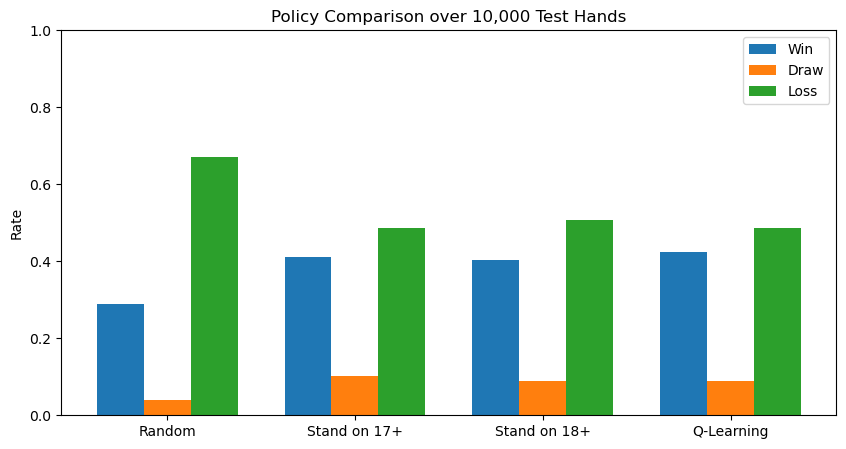

In [9]:
policy_names = list(results.keys())
win_rates = [results[name]["win_rate"] for name in policy_names]
draw_rates = [results[name]["draw_rate"] for name in policy_names]
loss_rates = [results[name]["lose_rate"] for name in policy_names]

x = np.arange(len(policy_names))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, win_rates, width, label="Win")
plt.bar(x, draw_rates, width, label="Draw")
plt.bar(x + width, loss_rates, width, label="Loss")

plt.xticks(x, policy_names)
plt.ylabel("Rate")
plt.title(f"Policy Comparison over {N_TEST_EPISODES:,} Test Hands")
plt.ylim(0, 1)
plt.legend()
plt.show()

## 8. Visualize Q-Learning Training Progress

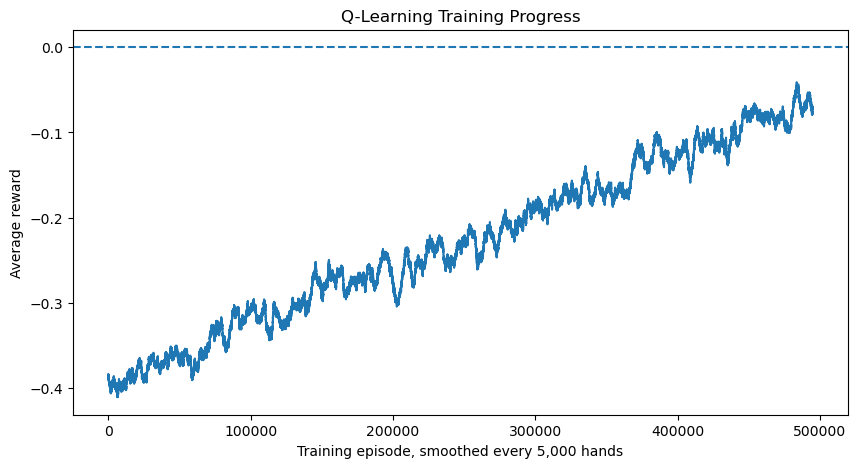

In [10]:
def moving_average(values, window=500):
    """Smooth reward values so the trend is easier to see."""
    values = np.array(values)

    if len(values) < window:
        return values

    weights = np.ones(window) / window
    return np.convolve(values, weights, mode="valid")


window = min(5000, max(1, len(training_rewards) // 10))
smoothed_rewards = moving_average(training_rewards, window=window)

plt.figure(figsize=(10, 5))
plt.plot(smoothed_rewards)
plt.axhline(0, linestyle="--")
plt.xlabel(f"Training episode, smoothed every {window:,} hands")
plt.ylabel("Average reward")
plt.title("Q-Learning Training Progress")
plt.show()

## 9. Interpreting the Results

The best evidence is not only the win rate. Look at:

- **Win rate:** higher is better.
- **Loss rate:** lower is better.
- **Average reward:** usually the most important metric because Blackjack rewards are `+1`, `0`, and `-1`.

A strong conclusion would be:

> The Q-learning policy achieved a higher win rate and average reward than the simple baselines, showing that reinforcement learning learned a stronger decision policy than fixed threshold strategies.

If Q-learning has a higher win rate but also a higher loss rate, explain that it is more aggressive and use **average reward** as the main comparison.

## 10. Future Improvement: Surrounding Cards / Other Players

The current Gymnasium Blackjack environment only gives the agent the player's sum, the dealer's visible card, and whether the player has a usable ace. It does **not** show other players' cards, and it does **not** track a finite deck.

For a future extension, we could build a custom Blackjack environment where the state also includes visible cards from other players or counts of high cards already seen. That would allow a card-counting-style strategy, but it would be more complicated and easier to break. For this project, the safest working version is the Q-learning comparison above.